### Mohammed Omar Mkhallati
### AI for Cybersecurity
### Monday, September 14, 2026
### CyberAttack Classifier
### Dataset Used: https://www.kaggle.com/datasets/ravikumargattu/network-traffic-dataset

#### Import Statements

In [1]:
import ssl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

#### Reading Dataset From My GitHub

In [2]:
ssl._create_default_https_context = ssl._create_unverified_context
github_url = "https://raw.githubusercontent.com/omarmkhallati/AI_For_Cybersecurity-Mkhallati/main/output1.csv"
df = pd.read_csv(github_url)

#### Confirm the Dataset was Read Properly

In [3]:
df.head()

,Timestamp,Source IP,Destination IP,Protocol,Length
0,1.696895e+09,192.167.8.166,192.167.255.255,17.0,92
1,1.696895e+09,192.167.8.166,192.167.255.255,17.0,92
2,1.696895e+09,NaN,NaN,NaN,60
3,1.696895e+09,NaN,NaN,NaN,60
4,1.696895e+09,NaN,NaN,NaN,60


#### Fixing Missing Values (Some Values do not Have a Source IP)

In [4]:
print("Rows before dropping:", len(df))
df = df.dropna(subset=["Source IP"])
print("Rows after dropping:", len(df))

Rows before dropping: 394136
Rows after dropping: 393502


#### Feature Engineering

In [5]:
agg = df.groupby("Source IP").agg(
    packet_count=("Length", "count"),
    avg_length=("Length", "mean"),
    std_length=("Length", "std"),
    unique_destinations=("Destination IP", "nunique"),
    protocol_diversity=("Protocol", "nunique"),
    first_seen=("Timestamp", "min"),
    last_seen=("Timestamp", "max"),
).reset_index()

agg["std_length"] = agg["std_length"].fillna(0)
agg["duration"] = (agg["last_seen"] - agg["first_seen"]).clip(lower=1)
agg["packet_rate"] = agg["packet_count"] / agg["duration"]

feature_cols = ["packet_count", "avg_length", "std_length", "unique_destinations",
                "protocol_diversity", "packet_rate"]
agg[feature_cols].describe()

,packet_count,avg_length,std_length,unique_destinations,protocol_diversity,packet_rate
count,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000
mean,1167.661721,550.955028,465.625397,1.887240,1.011869,4.909191
std,7676.328599,380.130462,213.316036,16.233024,0.133101,23.931705
min,1.000000,60.288288,0.000000,1.000000,1.000000,0.002769
25%,19.000000,291.210526,422.430826,1.000000,1.000000,0.163486
50%,37.000000,420.585366,528.451209,1.000000,1.000000,0.405229
75%,142.000000,761.284483,617.183829,1.000000,1.000000,1.622355
max,116067.000000,1497.891195,1059.291245,299.000000,3.000000,362.487368


#### Feature Scaling

In [6]:
X = agg[feature_cols].copy()
for c in ["packet_count", "std_length", "unique_destinations", "packet_rate"]:
    X[c] = np.log1p(X[c])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### K-Means Clustering

In [7]:
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    print(f"k={k}, silhouette={silhouette_score(X_scaled, labels):.3f}")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
agg["kmeans_cluster"] = kmeans.fit_predict(X_scaled)
agg["kmeans_cluster"].value_counts()

k=2, silhouette=0.899
k=3, silhouette=0.429
k=4, silhouette=0.543
k=5, silhouette=0.497
k=6, silhouette=0.515


kmeans_cluster
0    253
2     83
1      1
Name: count, dtype: int64

#### DBSCAN Clustering

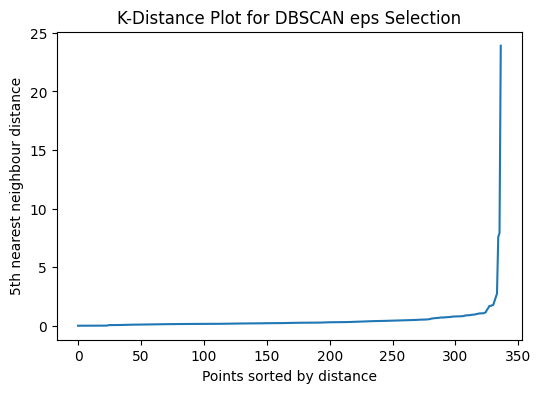

dbscan_cluster
 0    255
 2     36
-1     23
 1     13
 3     10
Name: count, dtype: int64

In [8]:
neighbors = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("5th nearest neighbour distance")
plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.show()

dbscan = DBSCAN(eps=0.8, min_samples=5)
agg["dbscan_cluster"] = dbscan.fit_predict(X_scaled)
agg["dbscan_cluster"].value_counts()

#### Hierarchial Clustering

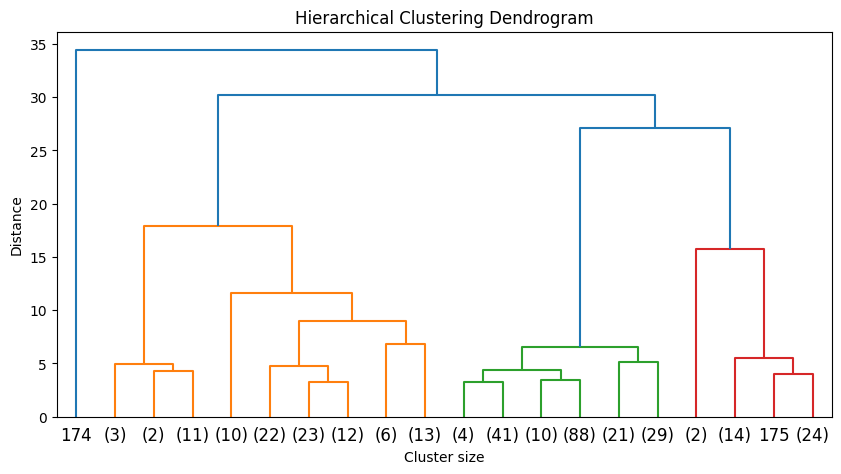

hierarchical_cluster
0    234
2    102
1      1
Name: count, dtype: int64

In [9]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()

hierarchical = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg["hierarchical_cluster"] = hierarchical.fit_predict(X_scaled)
agg["hierarchical_cluster"].value_counts()

#### Comparing K-Means, DBSCAN, and Hierarchial Clustering

K-Means silhouette score:        0.429
DBSCAN silhouette score (no noise): 0.562
Hierarchical silhouette score:    0.408
DBSCAN flagged 23 sources as noise/anomalies out of 337


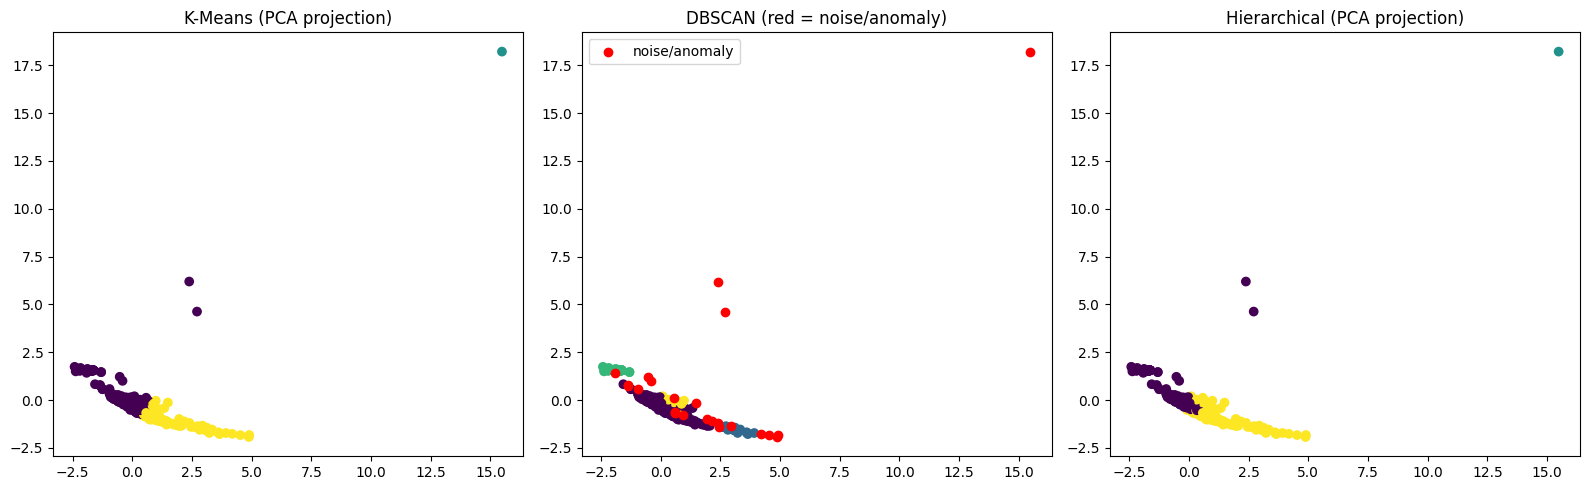

In [10]:
kmeans_sil = silhouette_score(X_scaled, agg["kmeans_cluster"])

mask = agg["dbscan_cluster"] != -1
dbscan_sil = silhouette_score(X_scaled[mask], agg.loc[mask, "dbscan_cluster"])

hierarchical_sil = silhouette_score(X_scaled, agg["hierarchical_cluster"])

n_noise = (agg["dbscan_cluster"] == -1).sum()

print(f"K-Means silhouette score:        {kmeans_sil:.3f}")
print(f"DBSCAN silhouette score (no noise): {dbscan_sil:.3f}")
print(f"Hierarchical silhouette score:    {hierarchical_sil:.3f}")
print(f"DBSCAN flagged {n_noise} sources as noise/anomalies out of {len(agg)}")

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(coords[:, 0], coords[:, 1], c=agg["kmeans_cluster"], cmap="viridis")
axes[0].set_title("K-Means (PCA projection)")

is_noise = agg["dbscan_cluster"] == -1
axes[1].scatter(coords[~is_noise, 0], coords[~is_noise, 1],
                 c=agg.loc[~is_noise, "dbscan_cluster"], cmap="viridis")
axes[1].scatter(coords[is_noise, 0], coords[is_noise, 1],
                 c="red", label="noise/anomaly")
axes[1].set_title("DBSCAN (red = noise/anomaly)")
axes[1].legend()

axes[2].scatter(coords[:, 0], coords[:, 1], c=agg["hierarchical_cluster"], cmap="viridis")
axes[2].set_title("Hierarchical (PCA projection)")

plt.tight_layout()
plt.show()

#### Abnormal or Suspicious Records

In [11]:
noise = agg[agg["dbscan_cluster"] == -1].sort_values("packet_count", ascending=False)
noise[["Source IP", "packet_count", "avg_length", "unique_destinations",
       "protocol_diversity", "packet_rate"]]

,Source IP,packet_count,avg_length,unique_destinations,protocol_diversity,packet_rate
174,192.167.7.162,116067,288.385674,299,3,96.872868
35,104.91.166.75,57238,1365.452566,1,1,153.523867
333,74.125.9.169,37085,1451.734151,1,1,44.893026
220,23.33.29.79,25918,1497.891195,1,1,109.203132
34,104.91.166.113,18222,1382.456481,1,1,362.487368
106,146.75.78.73,6254,126.289095,1,1,8.161778
77,142.250.190.46,4590,942.531155,1,1,6.402788
79,142.250.190.68,4267,1156.646590,1,1,4.287288
97,142.251.32.14,2269,937.156897,1,1,6.386760
292,35.186.194.58,1694,90.600354,1,1,2.349977
